# 02 Data Cleaning

Validacion de reglas de limpieza estructural sobre una muestra balanceada de `RAW.YELLOW_TRIPS_DEV` y `RAW.GREEN_TRIPS_DEV`. Este notebook toma los hallazgos descriptivos del EDA y los convierte en reglas concretas que luego deben implementarse del lado de Snowflake antes de construir `STAGING` y la OBT final.

## Objetivo del notebook

El objetivo no es limpiar toda la base en pandas, sino demostrar con evidencia muestral que las reglas elegidas eliminan viajes inviables o inconsistentes y que esa logica debe vivir en SQL para mantener escalabilidad, trazabilidad y control de leakage.

## Que se prueba en esta etapa

- validez temporal de `pickup_datetime` y `dropoff_datetime`
- consistencia minima de `trip_distance`, `fare_amount` y `passenger_count`
- presencia de zonas de origen y destino
- impacto cuantitativo de cada filtro sobre la muestra combinada
- ejemplos invalidos que permitan justificar las reglas sin arbitrariedad

## Resultado esperado

Al terminar este notebook debe quedar cerrada la capa de limpieza estructural que alimenta `STAGING`: reglas simples, defendibles, aplicables por pushdown y consistentes con el problema de prediccion pre-viaje.


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
elif not (PROJECT_ROOT / 'src').exists() and (PROJECT_ROOT.parent / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print('PROJECT_ROOT =', PROJECT_ROOT)


PROJECT_ROOT = /home/pabseb/DataMining/final-project/price-prediction-ml-end-to-end


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from src.data.ingestion import balanced_raw_sample_sql, fetch_sample
from src.features.build_features import DISTANCE_COLUMN, build_candidate_modeling_frame, normalize_raw_taxi_frame
from src.utils.config import get_settings

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 100)
settings = get_settings()
raw_sample = fetch_sample(
    balanced_raw_sample_sql(settings, limit=12000, sample_seed=settings.eda_sample_seed),
    limit=12000,
    sample_seed=settings.eda_sample_seed,
    settings=settings,
)
normalized_raw = normalize_raw_taxi_frame(raw_sample)
candidate_sample = build_candidate_modeling_frame(
    raw_sample,
    start_date=settings.data_start_date,
    end_date=settings.data_end_date,
)
assert not raw_sample.empty, 'La muestra raw esta vacia.'
assert not candidate_sample.empty, 'La muestra candidata quedo vacia. Revisa reglas o ingesta.'
print('raw sample =', raw_sample.shape)
print('sample by trip_type =')
print(normalized_raw['trip_type'].value_counts(dropna=False).sort_index())
print('candidate sample =', candidate_sample.shape)
normalized_raw.head()


raw sample = (12000, 19)
sample by trip_type =
trip_type
green     6000
yellow    6000
Name: count, dtype: int64
candidate sample = (9742, 20)


,trip_type,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,trip_distance,ratecode_id,pickup_location_id,dropoff_location_id,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,estimated_distance
0,yellow,2,2025-02-24 07:07:19,2025-02-24 07:15:13,1.0,1.44,1.0,262,140,1.0,10.70,0.0,0.5,15.01,0.0,1.0,29.71,2.50,0.0,1.44
1,green,2,2025-06-24 07:21:10,2025-06-24 07:41:21,1.0,3.08,1.0,134,216,1.0,20.50,0.0,0.5,0.00,0.0,1.0,22.00,0.00,NaN,3.08
2,yellow,2,2025-05-30 10:44:48,2025-05-30 11:01:28,NaN,2.25,NaN,48,237,0.0,16.49,0.0,0.5,0.00,0.0,1.0,21.24,NaN,NaN,2.25
3,green,1,2025-06-11 07:44:14,2025-06-11 08:08:52,4.0,5.20,1.0,166,161,1.0,27.50,3.5,1.5,3.25,0.0,1.0,35.75,2.75,NaN,5.20
4,green,2,2025-01-17 17:29:10,2025-01-17 17:37:21,1.0,0.89,1.0,75,236,1.0,9.30,2.5,0.5,3.21,0.0,1.0,19.26,2.75,NaN,0.89


In [3]:
raw_required = [
    'pickup_datetime', 'dropoff_datetime', 'passenger_count', 'trip_distance',
    'pulocationid', 'dolocationid', 'fare_amount'
]
missing_raw = sorted(set(raw_required).difference(raw_sample.columns))
assert not missing_raw, f'Faltan columnas esperadas en RAW: {missing_raw}'
raw_sample['trip_duration_min'] = (pd.to_datetime(raw_sample['dropoff_datetime']) - pd.to_datetime(raw_sample['pickup_datetime'])).dt.total_seconds() / 60
raw_sample[["pickup_datetime", "dropoff_datetime", "trip_duration_min"]].head()


,pickup_datetime,dropoff_datetime,trip_duration_min
0,2025-02-24 07:07:19,2025-02-24 07:15:13,7.900000
1,2025-06-24 07:21:10,2025-06-24 07:41:21,20.183333
2,2025-05-30 10:44:48,2025-05-30 11:01:28,16.666667
3,2025-06-11 07:44:14,2025-06-11 08:08:52,24.633333
4,2025-01-17 17:29:10,2025-01-17 17:37:21,8.183333


In [4]:
pickup_dates = pd.to_datetime(raw_sample["pickup_datetime"], errors="coerce").dt.date
rule_table = pd.DataFrame({
    'rule': [
        'pickup not null', 'dropoff not null', 'pickup in configured range', 'dropoff after pickup',
        'trip_distance > 0', 'passenger_count between 1 and 6', 'fare_amount > 0',
        'pickup location not null', 'dropoff location not null'
    ],
    'rows_passing': [
        raw_sample['pickup_datetime'].notna().sum(),
        raw_sample['dropoff_datetime'].notna().sum(),
        pickup_dates.between(pd.to_datetime(settings.data_start_date).date(), pd.to_datetime(settings.data_end_date).date()).sum(),
        (raw_sample['trip_duration_min'] > 0).sum(),
        (raw_sample['trip_distance'] > 0).sum(),
        raw_sample['passenger_count'].between(1, 6).sum(),
        (raw_sample['fare_amount'] > 0).sum(),
        raw_sample['pulocationid'].notna().sum(),
        raw_sample['dolocationid'].notna().sum(),
    ],
})
rule_table['pass_pct'] = (rule_table['rows_passing'] / len(raw_sample) * 100).round(2)
rule_table


,rule,rows_passing,pass_pct
0,pickup not null,12000,100.00
1,dropoff not null,12000,100.00
2,pickup in configured range,12000,100.00
3,dropoff after pickup,11917,99.31
4,trip_distance > 0,11546,96.22
5,passenger_count between 1 and 6,10239,85.32
6,fare_amount > 0,11663,97.19
7,pickup location not null,12000,100.00
8,dropoff location not null,12000,100.00


In [5]:
invalid_examples = raw_sample.loc[
    ~(
        raw_sample["pickup_datetime"].notna()
        & raw_sample["dropoff_datetime"].notna()
        & (raw_sample["trip_duration_min"] > 0)
        & (raw_sample["trip_distance"] > 0)
        & raw_sample["passenger_count"].between(1, 6)
        & (raw_sample["fare_amount"] > 0)
        & raw_sample["pulocationid"].notna()
        & raw_sample["dolocationid"].notna()
    ),
    [
        "trip_type", "vendorid", "pickup_datetime", "dropoff_datetime", "passenger_count",
        "trip_distance", "pulocationid", "dolocationid", "fare_amount", "trip_duration_min"
    ]
]
invalid_examples.head(15)


,trip_type,vendorid,pickup_datetime,dropoff_datetime,passenger_count,trip_distance,pulocationid,dolocationid,fare_amount,trip_duration_min
2,yellow,2,2025-05-30 10:44:48,2025-05-30 11:01:28,NaN,2.25,48,237,16.49,16.666667
6,yellow,2,2025-05-22 18:42:54,2025-05-22 18:57:18,NaN,0.00,262,237,-1.34,14.400000
10,yellow,2,2025-01-16 18:17:40,2025-01-16 18:32:50,NaN,0.02,230,238,21.73,15.166667
13,green,1,2025-03-28 08:26:01,2025-03-28 08:55:30,1.0,0.00,258,71,25.50,29.483333
15,yellow,2,2025-05-16 10:50:33,2025-05-16 10:58:11,NaN,1.11,151,239,-4.00,7.633333
36,yellow,1,2025-05-01 08:39:41,2025-05-01 09:03:01,0.0,3.00,107,237,18.40,23.333333
45,green,2,2025-05-21 11:28:00,2025-05-21 11:42:00,NaN,2.30,166,239,17.12,14.000000
47,yellow,2,2025-03-18 18:49:54,2025-03-18 19:10:17,NaN,0.02,61,36,20.24,20.383333
52,yellow,1,2025-04-16 11:34:23,2025-04-16 11:48:12,0.0,3.80,238,50,20.50,13.816667
56,yellow,2,2025-04-14 22:26:32,2025-04-14 22:36:55,NaN,2.08,186,113,11.95,10.383333


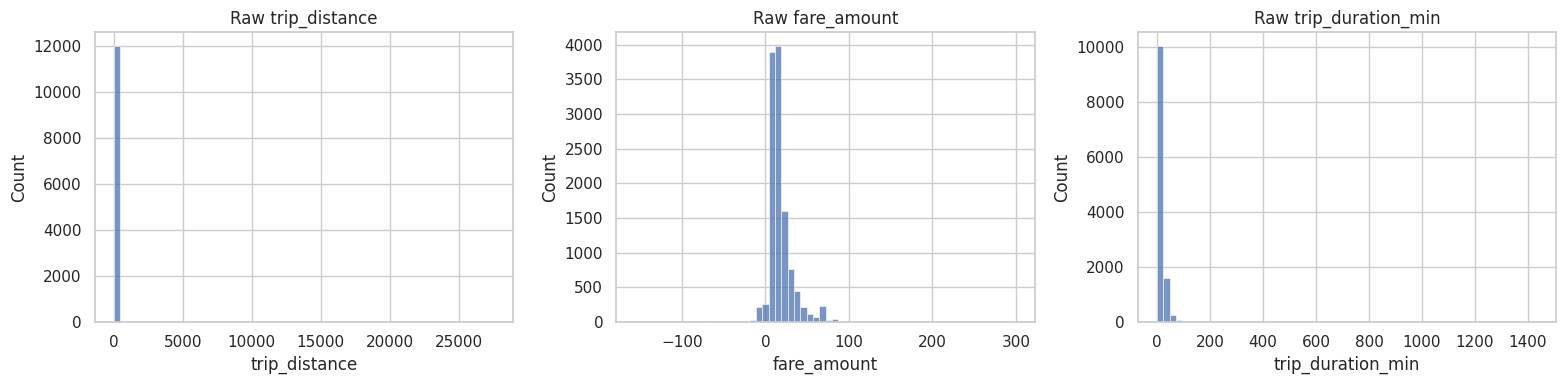

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(raw_sample['trip_distance'], bins=60, ax=axes[0])
axes[0].set_title('Raw trip_distance')
sns.histplot(raw_sample['fare_amount'], bins=60, ax=axes[1])
axes[1].set_title('Raw fare_amount')
sns.histplot(raw_sample['trip_duration_min'].dropna(), bins=60, ax=axes[2])
axes[2].set_title('Raw trip_duration_min')
plt.tight_layout()


In [7]:
raw_vs_candidate = pd.DataFrame({
    'dataset': ['raw_sample', 'candidate_after_rules'],
    'rows': [len(raw_sample), len(candidate_sample)],
    'fare_amount_mean': [raw_sample['fare_amount'].mean(), candidate_sample['fare_amount'].mean()],
    'estimated_distance_mean': [normalized_raw[DISTANCE_COLUMN].mean(), candidate_sample[DISTANCE_COLUMN].mean()],
    'passenger_count_mean': [raw_sample['passenger_count'].mean(), candidate_sample['passenger_count'].mean()],
})
raw_vs_candidate


,dataset,rows,fare_amount_mean,estimated_distance_mean,passenger_count_mean
0,raw_sample,12000,17.792037,5.355322,1.289525
1,candidate_after_rules,9742,18.130639,3.040581,1.303634


In [8]:
sql_rules_final = pd.DataFrame({
    'sql_rule': [
        'pickup_datetime IS NOT NULL',
        'dropoff_datetime IS NOT NULL',
        'pickup date between configured start/end',
        'dropoff_datetime > pickup_datetime',
        'trip_distance > 0',
        'passenger_count BETWEEN 1 AND 6',
        'fare_amount > 0',
        'pulocationid IS NOT NULL',
        'dolocationid IS NOT NULL',
    ]
})
sql_rules_final


,sql_rule
0,pickup_datetime IS NOT NULL
1,dropoff_datetime IS NOT NULL
2,pickup date between configured start/end
3,dropoff_datetime > pickup_datetime
4,trip_distance > 0
5,passenger_count BETWEEN 1 AND 6
6,fare_amount > 0
7,pulocationid IS NOT NULL
8,dolocationid IS NOT NULL


## Conclusiones e interpretacion

- La muestra balanceada de `12000` filas deja `9742` registros candidatos despues de aplicar reglas estructurales. La perdida es relevante pero defendible: el objetivo no es maximizar filas crudas sino descartar observaciones incompatibles con un escenario pre-viaje serio.
- El cuello de botella principal no esta en zonas ni fechas: ambas pasan practicamente completas. Las mayores fuentes de descarte son `passenger_count` faltante o fuera de rango (`85.32%` de paso), `trip_distance <= 0` (`96.22%` de paso), `fare_amount <= 0` (`97.19%` de paso) y casos con orden temporal invalido (`99.31%` de paso).
- Con estos resultados, las reglas estructurales ya quedan suficientemente justificadas para vivir en SQL dentro de `STAGING`: `pickup/dropoff` validos, `dropoff > pickup`, `fare_amount > 0`, `trip_distance > 0`, `passenger_count BETWEEN 1 AND 6` y zonas no nulas.
- No aparece evidencia suficiente para imponer cortes superiores agresivos sobre `fare_amount`, `trip_distance` o duracion en esta etapa. Los extremos deben seguir visibles para analisis y experimentacion antes de decidir cualquier winsorizacion o clipping.
- Con esto ya esta cerrada la base de cleaning estructural. El siguiente notebook debe concentrarse en `feature engineering` sobre esta muestra candidata y verificar que el contrato final preserve `trip_type`, `estimated_distance` y las derivadas temporales sin introducir leakage.
